# Phase 3 — Classification Models
**AgroSense AI Pipeline**

Models trained and compared:
1. Decision Tree
2. Random Forest ← winner
3. Gradient Boosting
4. K-Nearest Neighbours
5. Support Vector Machine
6. Naive Bayes

Evaluation: Accuracy, Macro F1, ROC-AUC, Confusion Matrix, Cross-Validation

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics         import (accuracy_score, f1_score, classification_report,
                                      confusion_matrix, roc_auc_score)
from sklearn.model_selection import cross_val_score

plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3,'figure.dpi':120})

with open('processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']; X_val  = data['X_val'];  X_test  = data['X_test']
y_train = data['y_train']; y_val  = data['y_val'];  y_test  = data['y_test']
X_full  = data['X_scaled']; y_full = data['y_raw']
le      = data['le']
classes = data['class_names']
print(f'Loaded. Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}')

Loaded. Train=1540, Val=330, Test=330


## 3.1  Train All Models

In [2]:
MODELS = {
    'Decision Tree':     DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=200, max_depth=None,
                                                 min_samples_split=2, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                     max_depth=5, random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'SVM':               SVC(kernel='rbf', C=10, probability=True, random_state=42),
    'Naive Bayes':       GaussianNB(),
}

results = []
trained = {}

for name, model in MODELS.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc   = accuracy_score(y_val,   model.predict(X_val))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    test_f1   = f1_score(y_test, model.predict(X_test), average='macro')
    cv_scores = cross_val_score(model, X_full, y_full, cv=5, scoring='accuracy')
    
    try:
        proba   = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0
    
    results.append({
        'Model':        name,
        'Train Acc':    round(train_acc*100, 2),
        'Val Acc':      round(val_acc*100,   2),
        'Test Acc':     round(test_acc*100,  2),
        'Macro F1':     round(test_f1,       4),
        'ROC-AUC':      round(roc_auc,       4),
        'CV Mean':      round(cv_scores.mean()*100, 2),
        'CV Std':       round(cv_scores.std()*100,  2),
    })
    trained[name] = model
    print(f'done. Test: {test_acc*100:.2f}%')

results_df = pd.DataFrame(results).sort_values('Test Acc', ascending=False)
results_df

Training Decision Tree... done. Test: 98.18%
Training Random Forest... done. Test: 99.70%
Training Gradient Boosting... done. Test: 97.88%
Training KNN... done. Test: 96.67%
Training SVM... done. Test: 98.79%
Training Naive Bayes... done. Test: 99.09%


,Model,Train Acc,Val Acc,Test Acc,Macro F1,ROC-AUC,CV Mean,CV Std
1,Random Forest,100.00,98.79,99.70,0.9970,1.0000,99.09,0.29
5,Naive Bayes,99.35,99.09,99.09,0.9909,1.0000,99.14,0.30
4,SVM,99.48,99.39,98.79,0.9878,1.0000,98.50,0.51
0,Decision Tree,99.94,98.18,98.18,0.9817,0.9921,98.41,0.41
2,Gradient Boosting,100.00,97.27,97.88,0.9789,0.9999,98.36,0.72
3,KNN,97.79,97.58,96.67,0.9666,0.9966,96.91,0.80


## 3.2  Benchmark Visualisation

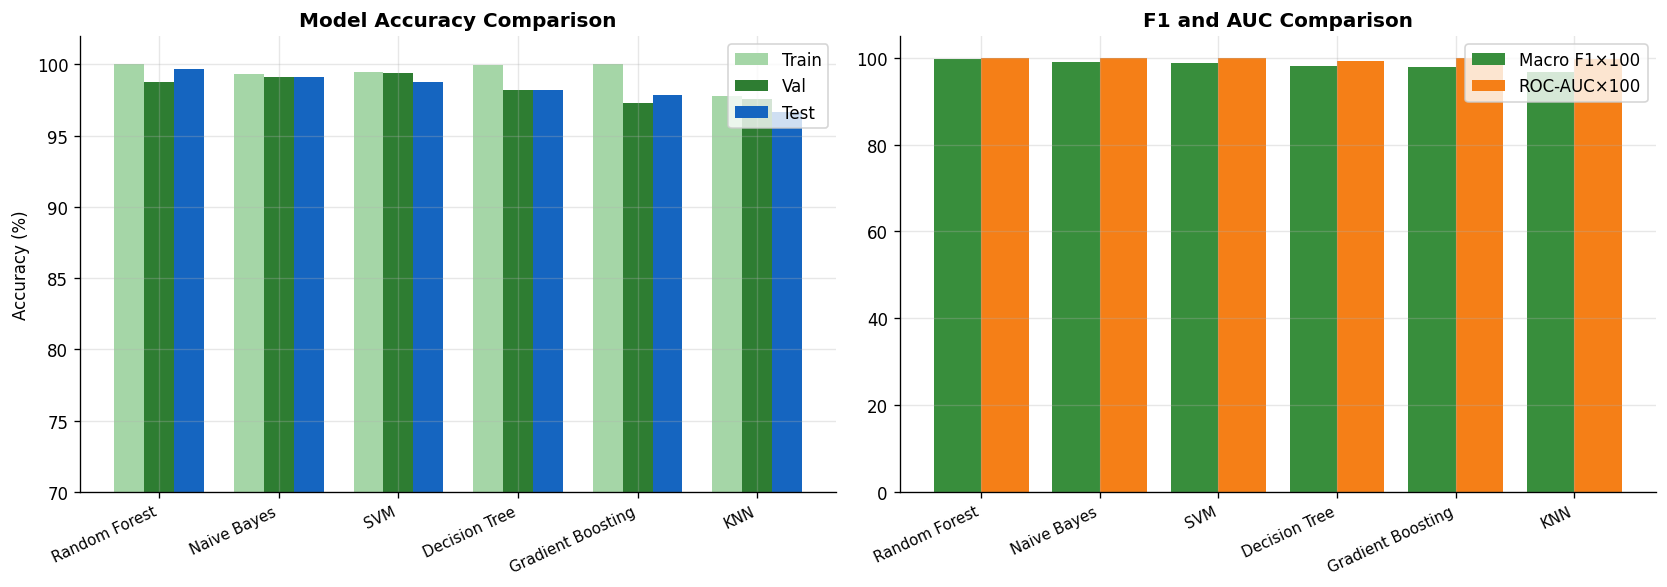

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
x = np.arange(len(results_df))
w = 0.25
axes[0].bar(x-w,   results_df['Train Acc'], w, label='Train', color='#A5D6A7')
axes[0].bar(x,     results_df['Val Acc'],   w, label='Val',   color='#2E7D32')
axes[0].bar(x+w,   results_df['Test Acc'],  w, label='Test',  color='#1565C0')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(70, 102)

# F1 and AUC
axes[1].bar(x-0.2, results_df['Macro F1']*100, 0.4, label='Macro F1×100', color='#388E3C')
axes[1].bar(x+0.2, results_df['ROC-AUC']*100,  0.4, label='ROC-AUC×100', color='#F57F17')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=9)
axes[1].set_title('F1 and AUC Comparison', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/phase3_benchmark.png', bbox_inches='tight')
plt.show()

## 3.3  Best Model — Detailed Analysis

In [4]:
best_name  = results_df.iloc[0]['Model']
best_model = trained[best_name]
print(f'Best model: {best_name}')
print()
print(classification_report(y_test, best_model.predict(X_test), target_names=classes))

Best model: Random Forest

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       1.00      1.00      1.00        15
      grapes       1.00      1.00      1.00        15
        jute       0.94      1.00      0.97        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       1.00      1.00      1.00        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      1.00      1.00        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       1.00      1.00      1.00        15


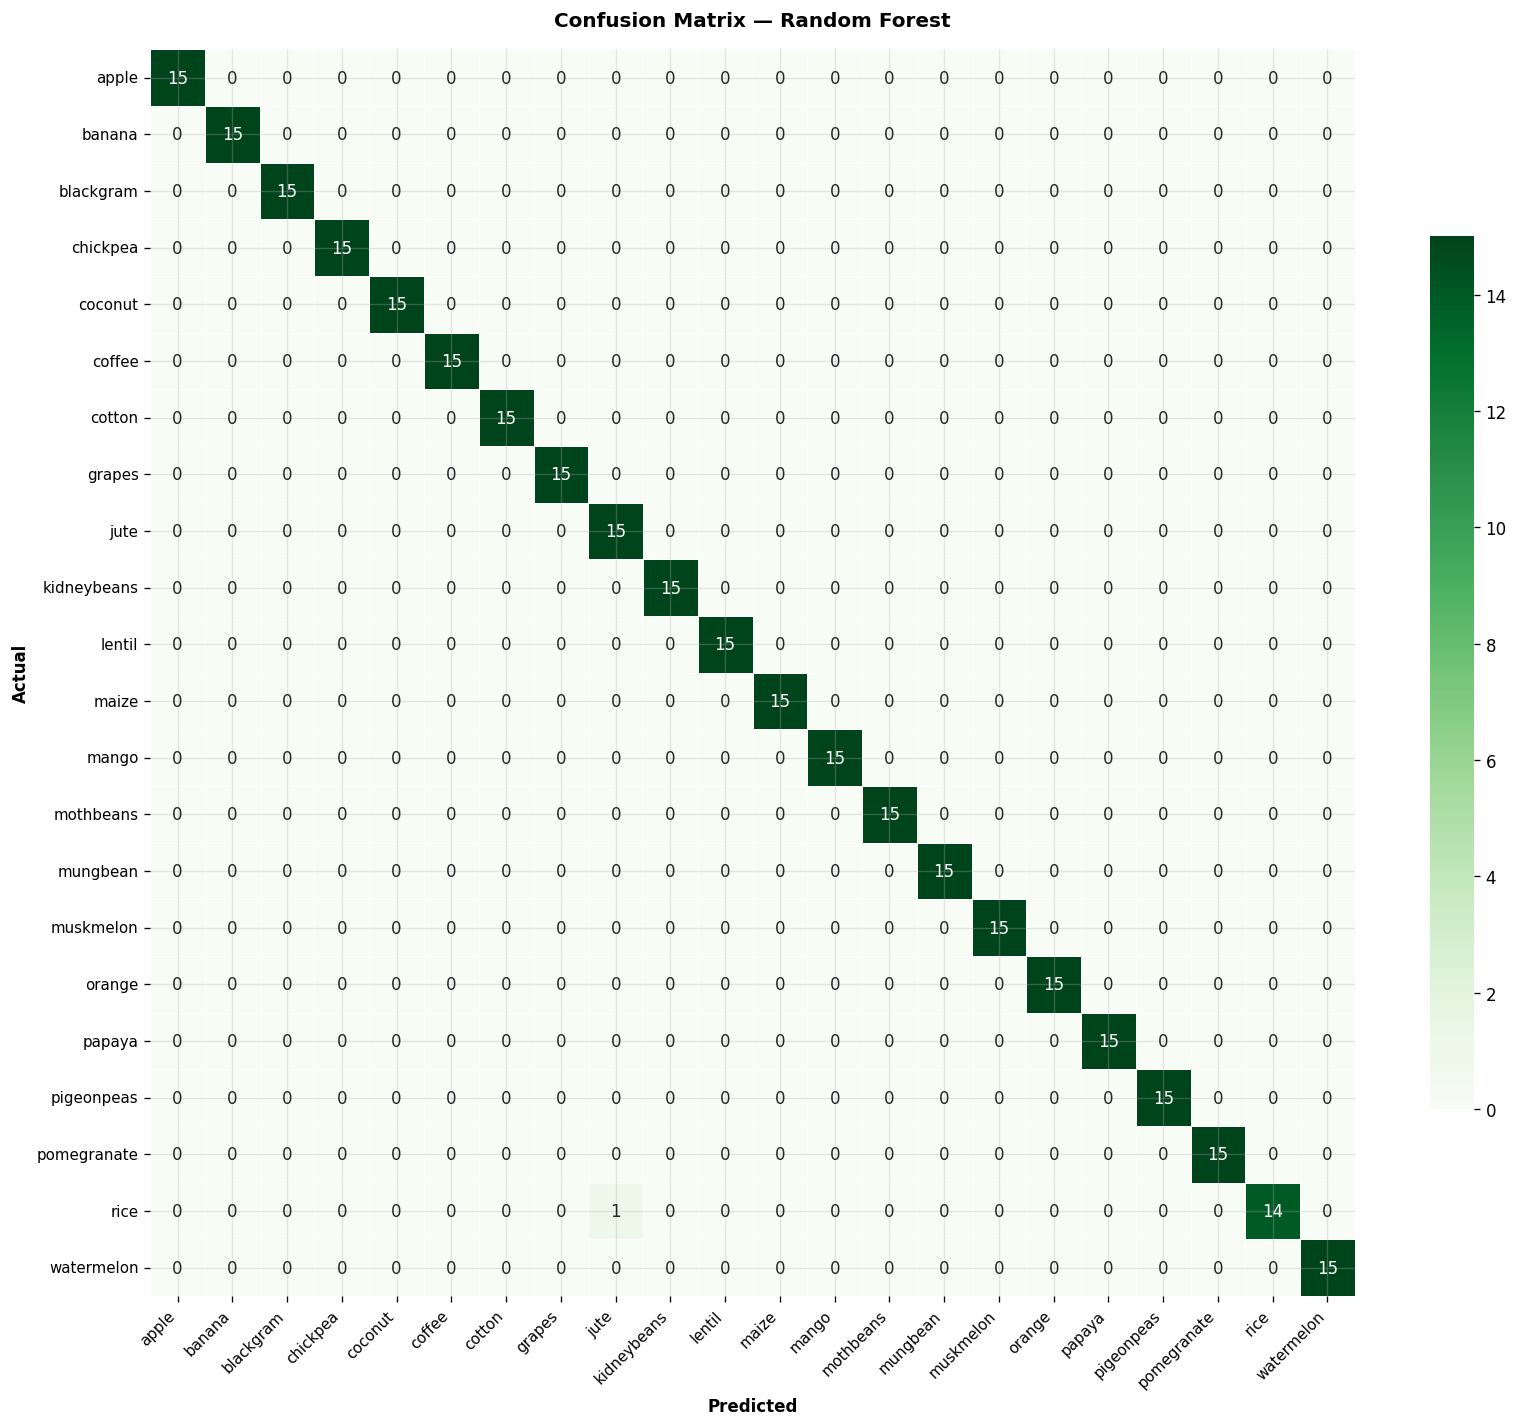

In [5]:
# Confusion matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.3, ax=ax, cbar_kws={'shrink':0.7})
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual',    fontweight='bold')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('outputs/phase3_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 3.4  Feature Importance (Random Forest)

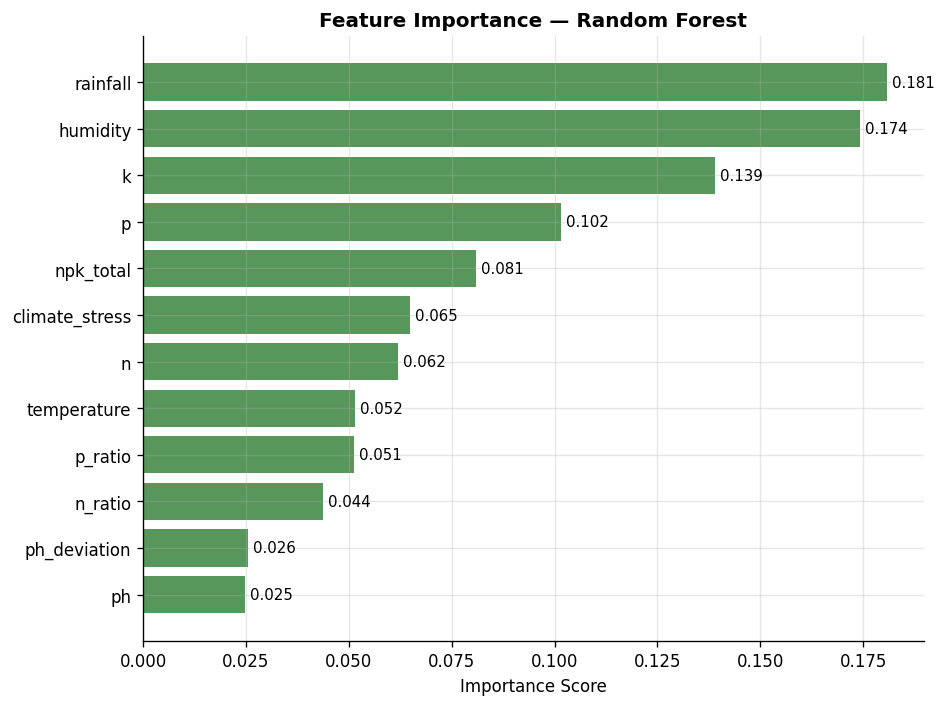

In [6]:
rf_model = trained.get('Random Forest', best_model)
if hasattr(rf_model, 'feature_importances_'):
    eng_features = data.get('eng_features', data['features'])
    fi_df = pd.DataFrame({'Feature': eng_features,
                           'Importance': rf_model.feature_importances_})
    fi_df = fi_df.sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color='#2E7D32', alpha=0.8)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title('Feature Importance — Random Forest', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('outputs/phase3_feature_importance.png', bbox_inches='tight')
    plt.show()

## 3.5  Cross-Validation Stability

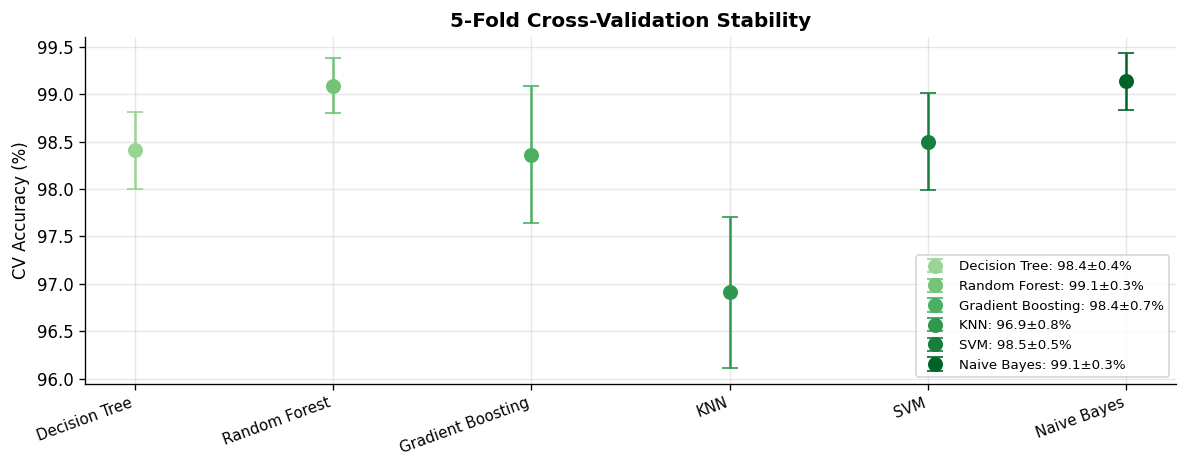

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, model) in enumerate(MODELS.items()):
    cv_s = cross_val_score(model, X_full, y_full, cv=5, scoring='accuracy')
    ax.errorbar(i, cv_s.mean()*100, yerr=cv_s.std()*100,
                fmt='o', capsize=5, markersize=8,
                color=plt.cm.Greens(0.4 + i*0.1),
                label=f'{name}: {cv_s.mean()*100:.1f}±{cv_s.std()*100:.1f}%')

ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(list(MODELS.keys()), rotation=20, ha='right', fontsize=9)
ax.set_ylabel('CV Accuracy (%)')
ax.set_title('5-Fold Cross-Validation Stability', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('outputs/phase3_cv_stability.png', bbox_inches='tight')
plt.show()

## 3.6  Save Best Model

In [8]:
import joblib

data['best_model']      = best_model
data['best_model_name'] = best_name
data['benchmark_df']    = results_df
data['trained_models']  = trained

with open('processed_data.pkl', 'wb') as f:
    pickle.dump(data, f)

joblib.dump(best_model, 'best_model.pkl')
print(f'Best model ({best_name}) saved to best_model.pkl')
print(f'Test accuracy: {results_df.iloc[0]["Test Acc"]}%')

Best model (Random Forest) saved to best_model.pkl
Test accuracy: 99.7%
